# Neural Ratio Estimation for Drift Diffusion Models

This notebook demonstrates how to:

1. Use the `ssm-simulators` `Simulator` class to generate DDM (Drift Diffusion Model) data
2. Train a BayesFlow `RatioApproximator` for Neural Ratio Estimation (NRE-C)
3. Extract a pure JAX single-trial log-ratio function from the trained network
4. Wrap it in PyTensor Ops with full gradient (VJP) support
5. Build a proper `pm.Distribution` and run NUTS sampling via PyMC

This follows the same architecture as `Ratio_Estimation_new.ipynb` but uses a
scientifically realistic DDM model with 4 parameters instead of a toy normal model.
No HSSM import is needed -- we build the full bridge manually.

**DDM parameters:** drift rate (v), boundary separation (a), starting point (z), non-decision time (t)
**Observations:** reaction time (rt) and choice (-1 or 1)

---
## Part 1: Train the Ratio Estimator

In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax"

import bayesflow as bf
import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import jax
import jax.numpy as jnp
from jax import jit, vjp, vmap
from jax.tree_util import Partial

import pymc as pm
import pytensor
import pytensor.tensor as pt
from pytensor.graph import Apply, Op
from pytensor.link.jax.dispatch import jax_funcify

from ssms.basic_simulators.simulator import simulator as ssm_simulator
from ssms.config import model_config as ssms_model_config

print(f"JAX backend: {keras.backend.backend()}")
print(f"JAX devices: {jax.devices()}")

INFO:2026-02-18 00:15:32,941:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:bayesflow:Using backend 'jax'
/Users/afengler/Library/CloudStorage/OneDrive-Personal/proj_bayesflow/bayesflow/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO

JAX backend: jax
JAX devices: [CpuDevice(id=0)]


In [2]:
LOAD_PRETRAINED = True  # <-- Set to True to skip training and load from disk
PRE_TRAINED_NAME = "ddm_ratio_approximator.keras"
SAVE_DIR = "trained_models"

### DDM Configuration

We read parameter names, bounds, and defaults directly from `ssm-simulators`.

In [3]:
# Read DDM config from ssm-simulators
ddm_cfg = ssms_model_config["ddm"]
param_names = ddm_cfg["params"]
param_lower = np.array(ddm_cfg["param_bounds"][0])
param_upper = np.array(ddm_cfg["param_bounds"][1])
param_defaults = np.array(ddm_cfg["default_params"])

print("DDM parameters:")
for name, lo, hi, default in zip(param_names, param_lower, param_upper, param_defaults):
    print(f"  {name:5s}: bounds=[{lo:5.2f}, {hi:5.2f}], default={default}")
print(f"Choices: {ddm_cfg['choices']}")

DDM parameters:
  v    : bounds=[-3.00,  3.00], default=0.0
  a    : bounds=[ 0.30,  2.50], default=1.0
  z    : bounds=[ 0.10,  0.90], default=0.5
  t    : bounds=[ 0.00,  2.00], default=0.001
Choices: [-1, 1]


### Generative Model

The DDM generates a reaction time (rt) and a binary choice (-1 or 1) for each trial.
We use `ssms.Simulator` to run the simulator. The prior is uniform over the training bounds.

In [4]:
# Use the ssm-simulators function-based API (v0.11.x)
# No Simulator class in this version -- we use the `simulator` function directly

def prior():
    """Sample DDM parameters uniformly from the training bounds."""
    params = {}
    for name, lo, hi in zip(param_names, param_lower, param_upper):
        params[name] = np.random.uniform(lo, hi)
    return params


def likelihood(v, a, z, t):
    """Simulate a single DDM trial and return [rt, choice] as the observation."""
    result = ssm_simulator(
        theta={"v": v, "a": a, "z": z, "t": t},
        model="ddm",
        n_samples=1,
    )
    rt = float(result["rts"].flat[0])
    choice = float(result["choices"].flat[0])
    return {"obs": np.array([rt, choice], dtype=np.float32)}


# Quick sanity check
test_params = prior()
test_obs = likelihood(**test_params)
print(f"Test params: {test_params}")
print(f"Test observation: rt={test_obs['obs'][0]:.4f}, choice={test_obs['obs'][1]:.0f}")

Test params: {'v': 1.471393487667857, 'a': 1.2678417905742918, 'z': 0.20779450674664288, 't': 0.7963649584469137}
Test observation: rt=3.2497, choice=1


In [5]:
simulator = bf.make_simulator([prior, likelihood])

# Quick test
test_sims = simulator.sample(3)
for k, v in test_sims.items():
    print(k, v.shape)

v (3, 1)
a (3, 1)
z (3, 1)
t (3, 1)
obs (3, 2)


### Build Adapter & Train

In [6]:
if not LOAD_PRETRAINED:
    adapter = bf.approximators.RatioApproximator.build_adapter(
        inference_variables=["v", "a", "z", "t"],
        inference_conditions=["obs"],  # 2D: [rt, choice]
    )

    ratio_approximator = bf.approximators.RatioApproximator(
        adapter=adapter,
        # Wider network for 6D input (4 params + 2 obs dims)
        classifier_network=bf.networks.MLP(widths=[256, 256, 256]),
        standardize=None,
    )

In [7]:
if not LOAD_PRETRAINED:
    ratio_approximator.compile(optimizer="adam")

    history = ratio_approximator.fit(
        simulator=simulator,
        epochs=50,
        num_batches=200,
        batch_size=64,
    )

In [8]:
if not LOAD_PRETRAINED:
    f = bf.diagnostics.plots.loss(history)

In [9]:
import os

if not LOAD_PRETRAINED:
    # Save the trained approximator for fast reloading
    os.makedirs(SAVE_DIR, exist_ok=True)
    save_path = os.path.join(SAVE_DIR, PRE_TRAINED_NAME)

    ratio_approximator.save(save_path)
    print(f"Approximator saved to: {save_path}")

### Load a Pre-trained Approximator (Optional)

Set `LOAD_PRETRAINED = True` to skip training and load from disk instead.
This is useful for fast iteration on the downstream PyMC pipeline.

In [10]:
if LOAD_PRETRAINED:
    load_path = os.path.join("trained_models", PRE_TRAINED_NAME)
    ratio_approximator = keras.saving.load_model(load_path)
    print(f"Loaded pre-trained approximator from: {load_path}")
else:
    print("Using in-memory approximator from training above.")

Loaded pre-trained approximator from: trained_models/ddm_ratio_approximator.keras


### Sanity Check: Positive vs. Contrastive Log-Ratios

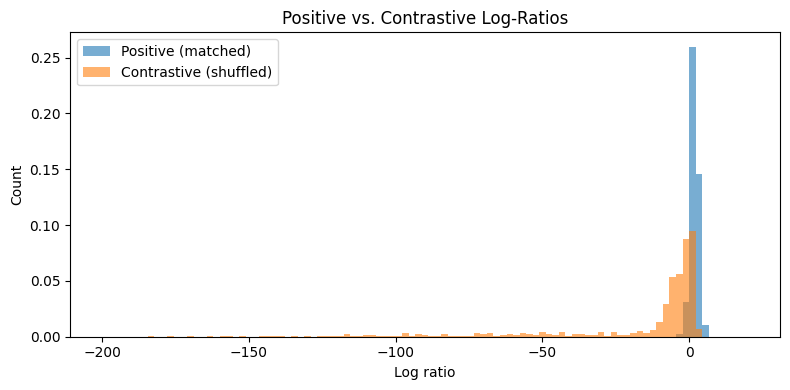

Positive mean: 1.786, Contrastive mean: -16.854


In [11]:
sims = simulator.sample(1000)

# Create contrastive pairs by shuffling parameters
contrastive_sims = {
    "v": sims["v"][::-1],
    "a": sims["a"][::-1],
    "z": sims["z"][::-1],
    "t": sims["t"][::-1],
    "obs": sims["obs"],
}

positive_lr = np.asarray(ratio_approximator.log_ratio(sims)).flatten()
contrastive_lr = np.asarray(ratio_approximator.log_ratio(contrastive_sims)).flatten()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(positive_lr, alpha=0.6, label="Positive (matched)", density=True, bins = np.linspace(-200, 20, 100))
ax.hist(contrastive_lr, alpha=0.6, label="Contrastive (shuffled)", density=True, bins = np.linspace(-200, 20, 100))
ax.set_xlabel("Log ratio")
ax.set_ylabel("Count")
ax.set_title("Positive vs. Contrastive Log-Ratios")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Positive mean: {positive_lr.mean():.3f}, Contrastive mean: {contrastive_lr.mean():.3f}")

---
## Part 2: Extract a JAX-native Single-Trial Function

We extract a pure JAX callable from the trained `RatioApproximator`.
The function has signature: `f(obs_i, v, a, z, t) -> scalar log_ratio`
where `obs_i` is a 2-element array `[rt, choice]` and the parameters are scalars.

In [12]:
def make_jax_log_ratio_fn(ratio_approximator):
    """Extract a pure JAX single-trial log-ratio callable from a trained RatioApproximator.

    Returns a function with signature: f(obs_i, v, a, z, t) -> scalar log_ratio
    where obs_i is shape (2,) = [rt, choice], and v, a, z, t are JAX scalars.
    """
    classifier = ratio_approximator.classifier_network
    projector = ratio_approximator.projector

    # Capture standardization layers if they exist
    std_layers = ratio_approximator.standardize_layers if hasattr(ratio_approximator, "standardize_layers") else {}
    std_keys = ratio_approximator.standardize if hasattr(ratio_approximator, "standardize") else []
    if std_layers is None:
        std_layers = {}
    if std_keys is None:
        std_keys = []

    def single_trial_log_ratio(obs_i, *params):
        """Compute log-ratio for a single DDM trial.

        Parameters
        ----------
        obs_i : shape (2,) array [rt, choice]
        *params : (v, a, z, t) as scalars

        Returns
        -------
        scalar log_ratio
        """
        inf_vars = jnp.array(list(params))  # shape (4,)
        inf_conds = jnp.atleast_1d(obs_i)   # shape (2,)

        # Apply standardization if configured
        if "inference_variables" in std_keys and "inference_variables" in std_layers:
            inf_vars = std_layers["inference_variables"](inf_vars[None, :], training=False)[0]
        if "inference_conditions" in std_keys and "inference_conditions" in std_layers:
            inf_conds = std_layers["inference_conditions"](inf_conds[None, :], training=False)[0]

        # Concatenate: [v, a, z, t, rt, choice] -- same order as the adapter produces
        classifier_input = jnp.concatenate([inf_vars, inf_conds])

        # Add batch dim, run network, remove batch dim
        hidden = classifier(classifier_input[None, :], training=False)
        logits = projector(hidden, training=False)
        return jnp.squeeze(logits)

    return single_trial_log_ratio


single_trial_fn = make_jax_log_ratio_fn(ratio_approximator)

# Quick test
test_obs = jnp.array([0.8, 1.0])  # rt=0.8, choice=1
test_val = single_trial_fn(test_obs, jnp.array(0.5), jnp.array(1.0), jnp.array(0.5), jnp.array(0.3))
print(f"Single trial log-ratio at (obs=[0.8, 1.0], v=0.5, a=1.0, z=0.5, t=0.3): {test_val:.4f}")

Single trial log-ratio at (obs=[0.8, 1.0], v=0.5, a=1.0, z=0.5, t=0.3): 1.5474


### Consistency Check: Extracted vs. Original

Verify that the extracted JAX function produces the same values as
the original `ratio_approximator.log_ratio()` method.

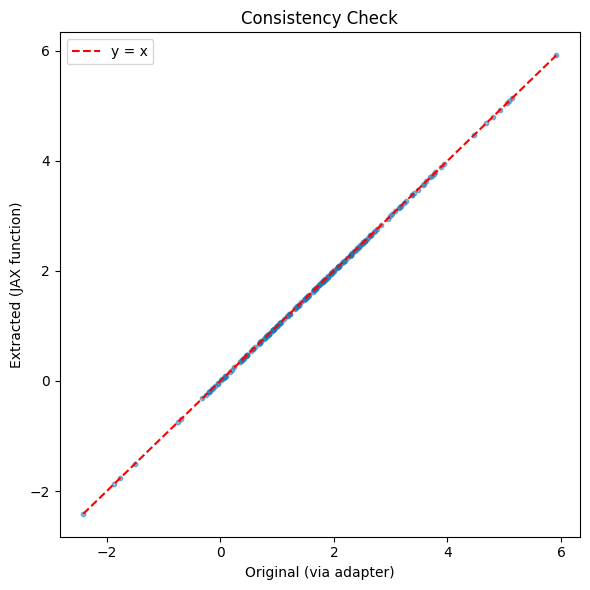

Max absolute difference: 0.000001


In [13]:
n_test = 200
test_data = simulator.sample(n_test)

# Original path: through the adapter
original_lr = np.asarray(ratio_approximator.log_ratio(test_data)).flatten()

# Extracted path: direct JAX calls
extracted_lr = np.array([
    float(single_trial_fn(
        jnp.array(test_data["obs"][i]),
        jnp.array(test_data["v"][i].item()),
        jnp.array(test_data["a"][i].item()),
        jnp.array(test_data["z"][i].item()),
        jnp.array(test_data["t"][i].item()),
    ))
    for i in range(n_test)
])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(original_lr, extracted_lr, alpha=0.5, s=10)
lo = min(original_lr.min(), extracted_lr.min())
hi = max(original_lr.max(), extracted_lr.max())
ax.plot([lo, hi], [lo, hi], "r--", label="y = x")
ax.set_xlabel("Original (via adapter)")
ax.set_ylabel("Extracted (JAX function)")
ax.set_title("Consistency Check")
ax.legend()
plt.tight_layout()
plt.show()

max_diff = np.max(np.abs(original_lr - extracted_lr))
print(f"Max absolute difference: {max_diff:.6f}")

---
## Part 2b: Investigate the Single-Trial Log-Ratio

Before wiring the function into PyTensor, let's visualise the learned
log-ratio landscape.

### Log-Ratio vs. Drift Rate (v) for Various Boundary Separations (a)

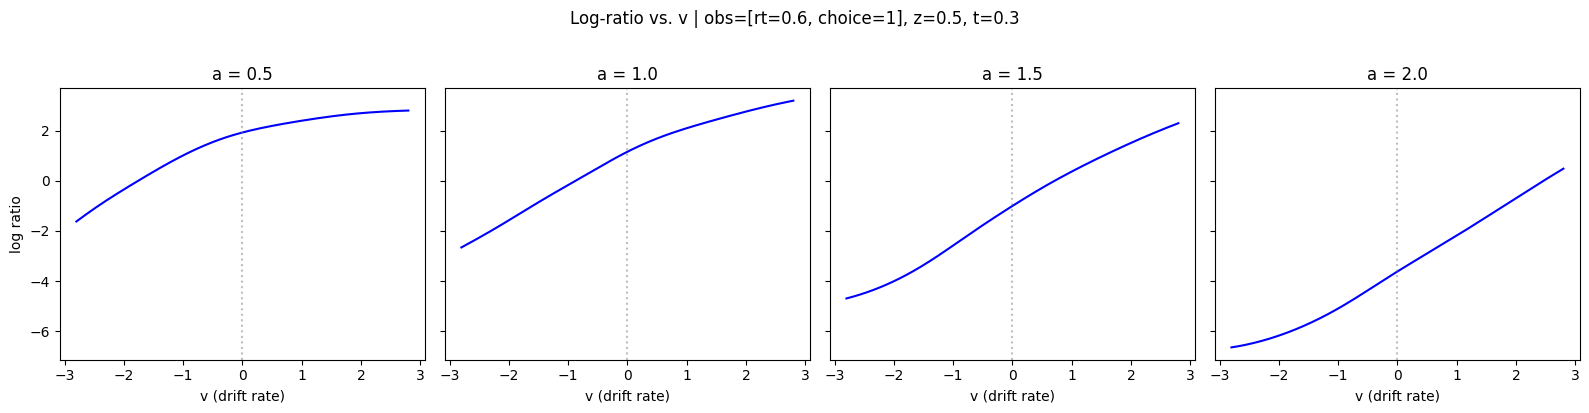

In [14]:
# Fix z and t at their defaults, sweep v for several a values
z_fix = 0.5
t_fix = 0.3
obs_fix = jnp.array([0.6, 1.0])  # a typical fast correct response

a_slices = [0.5, 1.0, 1.5, 2.0]
v_vals = np.linspace(-2.8, 2.8, 200)

fig, axes = plt.subplots(1, len(a_slices), figsize=(4 * len(a_slices), 4), sharey=True)

for ax, a_val in zip(axes, a_slices):
    lr_vals = np.array([
        float(single_trial_fn(obs_fix, jnp.array(v), jnp.array(a_val), jnp.array(z_fix), jnp.array(t_fix)))
        for v in v_vals
    ])
    ax.plot(v_vals, lr_vals, "b-", linewidth=1.5)
    ax.set_xlabel("v (drift rate)")
    ax.set_title(f"a = {a_val:.1f}")
    ax.axvline(0, color="gray", linestyle=":", alpha=0.5)

axes[0].set_ylabel("log ratio")
fig.suptitle(f"Log-ratio vs. v | obs=[rt={float(obs_fix[0]):.1f}, choice={float(obs_fix[1]):.0f}], z={z_fix}, t={t_fix}", y=1.02)
plt.tight_layout()
plt.show()

### 2D Log-Ratio Heatmap: (v, a) Plane

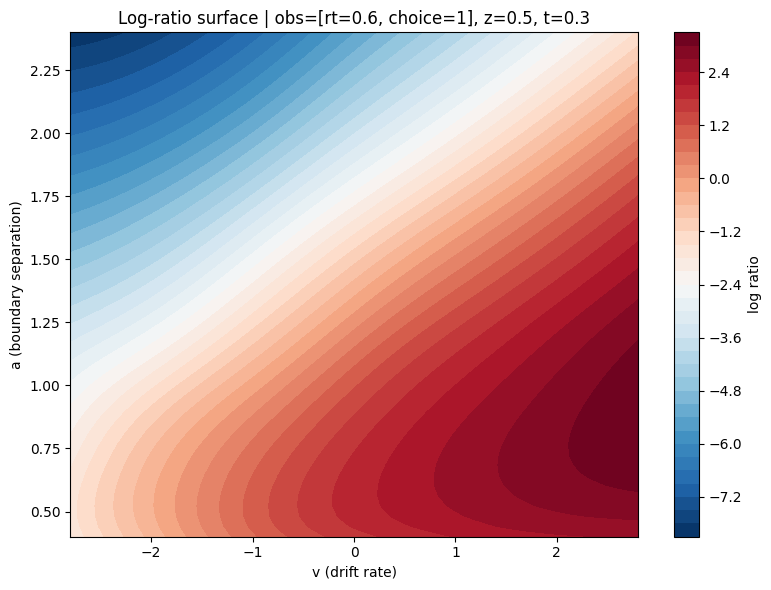

In [15]:
# Fix z=0.5, t=0.3, obs=[0.6, 1.0]
v_grid = np.linspace(-2.8, 2.8, 60)
a_grid = np.linspace(0.4, 2.4, 50)
V, A = np.meshgrid(v_grid, a_grid)

obs_2d = jnp.array([0.6, 1.0])
lr_surface = np.zeros_like(V)
for i in range(V.shape[0]):
    for j in range(V.shape[1]):
        lr_surface[i, j] = float(single_trial_fn(
            obs_2d,
            jnp.array(V[i, j]),
            jnp.array(A[i, j]),
            jnp.array(z_fix),
            jnp.array(t_fix),
        ))

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.contourf(V, A, lr_surface, levels=40, cmap="RdBu_r")
plt.colorbar(im, ax=ax, label="log ratio")
ax.set_xlabel("v (drift rate)")
ax.set_ylabel("a (boundary separation)")
ax.set_title(f"Log-ratio surface | obs=[rt=0.6, choice=1], z={z_fix}, t={t_fix}")
plt.tight_layout()
plt.show()

---
## Part 3: Wrap in PyTensor Op with Gradient Support (HSSM-style)

We replicate the key utility functions from HSSM's `distribution_utils` inline.
These create vmapped + VJP versions of the single-trial function and wrap them
in PyTensor Ops with full gradient support for NUTS sampling.

In [16]:
# ========================================================
# Replicated from HSSM's func_utils.py (self-contained)
# ========================================================

def make_vjp_func(logp, params_only=False):
    """Make a non-jitted VJP of the logp function."""
    def vjp_logp(*inputs, gz=None, params_only=False):
        _, vjp_fn = vjp(logp, *inputs)
        if params_only:
            return vjp_fn(gz)
        else:
            return vjp_fn(gz)[1:]  # skip data gradient
    vjp_logp = Partial(vjp_logp, params_only=params_only)
    return vjp_logp


def make_vmap_func(logp, in_axes, params_only=False):
    """Make a vectorized version of the logp function, its VJP, and the nojit version."""
    vmap_logp = vmap(logp, in_axes=in_axes)
    vjp_vmap_logp = make_vjp_func(vmap_logp, params_only=params_only)
    return jit(vmap_logp), jit(vjp_vmap_logp), vmap_logp


def make_jax_logp_funcs_from_callable(logp, params_is_reg, params_only=False):
    """Build vmap + VJP wrappers from a single-trial JAX callable."""
    in_axes = [0 if is_reg else None for is_reg in params_is_reg]
    if not params_only:
        in_axes.insert(0, 0)  # data axis is always vectorized
    return make_vmap_func(logp, in_axes=in_axes, params_only=params_only)

In [17]:
# ========================================================
# Replicated from HSSM's jax.py (self-contained)
# ========================================================

def make_jax_logp_ops(logp, logp_vjp, logp_nojit):
    """Wrap JAX functions and their gradient in PyTensor Ops."""

    class LANLogpOp(Op):
        def make_node(self, data, *dist_params):
            inputs = [pt.as_tensor_variable(p) for p in dist_params]
            self.has_data = data is not None
            if self.has_data:
                inputs = [pt.as_tensor_variable(data)] + inputs
            outputs = [pt.vector()]
            return Apply(self, inputs, outputs)

        def perform(self, node, inputs, output_storage):
            result = logp(*inputs)
            output_storage[0][0] = np.asarray(result, dtype=node.outputs[0].dtype)

        def grad(self, inputs, output_gradients):
            if self.has_data:
                results = lan_logp_vjp_op(
                    inputs[0], *inputs[1:], gz=output_gradients[0]
                )
            else:
                results = lan_logp_vjp_op(None, *inputs, gz=output_gradients[0])
            output = results
            if self.has_data:
                output = [
                    pytensor.gradient.grad_not_implemented(self, 0, inputs[0]),
                ] + output
            return output

    class LANLogpVJPOp(Op):
        def make_node(self, data, *dist_params, gz):
            self.has_data = data is not None
            inputs = [pt.as_tensor_variable(p) for p in dist_params]
            if self.has_data:
                inputs = [pt.as_tensor_variable(data)] + inputs
            inputs += [pt.as_tensor_variable(gz)]
            if self.has_data:
                outputs = [inp.type() for inp in inputs[1:-1]]
            else:
                outputs = [inp.type() for inp in inputs[:-1]]
            return Apply(self, inputs, outputs)

        def perform(self, node, inputs, outputs):
            if self.has_data:
                results = logp_vjp(*inputs[:-1], gz=inputs[-1])
            else:
                results = logp_vjp(*inputs[:-1], gz=inputs[-1])
            for i, result in enumerate(results):
                outputs[i][0] = np.asarray(result, dtype=node.outputs[i].dtype)

    lan_logp_op = LANLogpOp()
    lan_logp_vjp_op = LANLogpVJPOp()

    @jax_funcify.register(LANLogpOp)
    def logp_op_dispatch(op, **kwargs):
        return logp_nojit

    return lan_logp_op

### Wire Everything Together

In [18]:
# Build the Ops -- all 4 params are per-trial vectors
logp_jit, logp_vjp_jit, logp_nojit = make_jax_logp_funcs_from_callable(
    single_trial_fn,
    params_is_reg=[True, True, True, True],  # all 4 DDM params as vectors
)

ratio_op = make_jax_logp_ops(logp_jit, logp_vjp_jit, logp_nojit)
print("Op created:", ratio_op)

Op created: LANLogpOp


---
## Part 4: Build a Proper `pm.Distribution`

A real PyMC distribution with:
- A `logp()` that accepts observed data + distribution parameters
- Parameters that can be scalars or per-trial vectors
- Gradient support enabling NUTS

In [19]:
from pytensor.tensor.random.op import RandomVariable

def make_ratio_distribution(ratio_op, list_params, simulator_fn=None):
    """Factory that creates a pm.Distribution class using the given ratio Op."""
    sig = ",".join(["()" for _ in list_params]) + "->(2)"

    class SimpleRV(RandomVariable):
        name = "ratio_rv"
        signature = sig
        dtype = "floatX"
        _print_name = ("DDM_RatioRV", "\\operatorname{DDM\\_RatioRV}")

        @classmethod
        def rng_fn(cls, rng, *args, **kwargs):
            if simulator_fn is not None:
                return simulator_fn(rng, *args, **kwargs)
            raise NotImplementedError("Sampling not implemented for this distribution.")

    class RatioDistribution(pm.Distribution):
        rv_op = SimpleRV()
        _params = list_params

        @classmethod
        def dist(cls, **kwargs):
            dist_params = [
                pt.as_tensor_variable(pm.floatX(kwargs[p])) for p in cls._params
            ]
            other_kwargs = {k: v for k, v in kwargs.items() if k not in cls._params}
            return super().dist(dist_params, **other_kwargs)

        def logp(data, *dist_params):
            # data is shape (n_obs, 2) for DDM [rt, choice]
            n_obs = data.shape[0]
            dist_params = tuple(
                pt.broadcast_to(p, (n_obs,)) for p in dist_params
            )
            return ratio_op(data, *dist_params)

    return RatioDistribution


DDMRatioDistribution = make_ratio_distribution(
    ratio_op,
    list_params=["v", "a", "z", "t"],
)

print("Distribution class created:", DDMRatioDistribution)

Distribution class created: <class '__main__.make_ratio_distribution.<locals>.RatioDistribution'>


---
## Part 5: PyMC Model with NUTS (Scalar Parameters)

All four DDM parameters are scalar (same value for all trials).
We use truncated priors that respect the training bounds and controlled
starting points to keep the sampler in the reliable region.

In [24]:
# Ground truth parameters
v_true = 0.5
a_true = 1.2
z_true = 0.5
t_true = 0.3
n_obs = 1000

# Simulate observed data using ssm-simulators function API
result = ssm_simulator(
    theta={"v": v_true, "a": a_true, "z": z_true, "t": t_true},
    model="ddm",
    n_samples=n_obs,
    random_state=42,
)

# Stack into (n_obs, 2) array: [rt, choice]
x_observed = np.column_stack([
    result["rts"].flatten(),
    result["choices"].flatten(),
]).astype(np.float32)

print(f"Observed data: n={n_obs}")
print(f"  RT   mean={x_observed[:, 0].mean():.3f}, std={x_observed[:, 0].std():.3f}")
print(f"  Choice proportions: {{-1: {(x_observed[:, 1] == -1).mean():.2f}, 1: {(x_observed[:, 1] == 1).mean():.2f}}}")
print(f"True params: v={v_true}, a={a_true}, z={z_true}, t={t_true}")

Observed data: n=1000
  RT   mean=1.594, std=1.096
  Choice proportions: {-1: 0.25, 1: 0.75}
True params: v=0.5, a=1.2, z=0.5, t=0.3


In [25]:
with pm.Model() as ddm_model:
    # --- Truncated priors matching the training bounds ---
    # v: drift rate, bounds [-3, 3]
    v = pm.TruncatedNormal("v", mu=0, sigma=1.5, lower=-3.0, upper=3.0)
    # a: boundary separation, bounds [0.3, 2.5]
    a = pm.TruncatedNormal("a", mu=1.0, sigma=0.5, lower=0.3, upper=2.5)
    # z: starting point, bounds [0.1, 0.9]
    z = pm.TruncatedNormal("z", mu=0.5, sigma=0.2, lower=0.1, upper=0.9)
    # t: non-decision time, bounds [0.0, 2.0]
    t = pm.TruncatedNormal("t", mu=0.3, sigma=0.3, lower=0.0, upper=2.0)

    obs = DDMRatioDistribution("obs", v=v, a=a, z=z, t=t, observed=x_observed)

    # --- Controlled starting points ---
    trace = pm.sample(
        1000,
        nuts_sampler="numpyro",
        chains=2,
        tune=1000,
        random_seed=42,
        mp_ctx=mp.get_context("spawn"),
        initvals={"v": 0.0, "a": 1.0, "z": 0.5, "t": 0.3},
    )

/Users/afengler/Library/CloudStorage/OneDrive-Personal/proj_bayesflow/bayesflow/.venv/lib/python3.12/site-packages/pymc/sampling/jax.py:475: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(
sample: 100%|██████████| 2000/2000 [01:32<00:00, 21.56it/s, 7 steps of size 6.28e-01. acc. prob=0.90] 


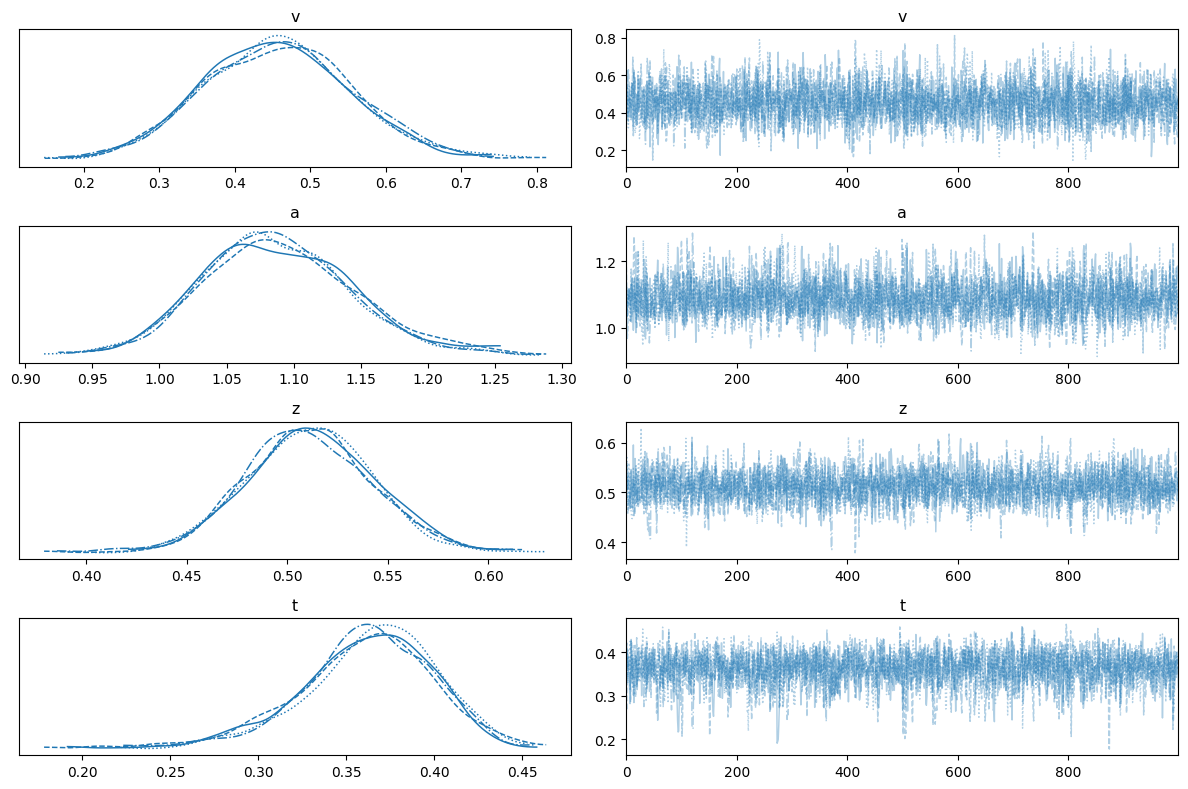

    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
v  0.457  0.099   0.278    0.646      0.002    0.002    3317.0    2687.0   
a  1.088  0.057   0.984    1.200      0.001    0.001    2387.0    2558.0   
z  0.511  0.032   0.455    0.572      0.001    0.001    2822.0    2328.0   
t  0.362  0.039   0.291    0.433      0.001    0.001    2603.0    2211.0   

   r_hat  
v    1.0  
a    1.0  
z    1.0  
t    1.0  

True values: v=0.5, a=1.2, z=0.5, t=0.3


In [22]:
import arviz as az

az.plot_trace(trace, var_names=["v", "a", "z", "t"])
plt.tight_layout()
plt.show()

print(az.summary(trace, var_names=["v", "a", "z", "t"]))
print(f"\nTrue values: v={v_true}, a={a_true}, z={z_true}, t={t_true}")

### Compare Posteriors with True Values

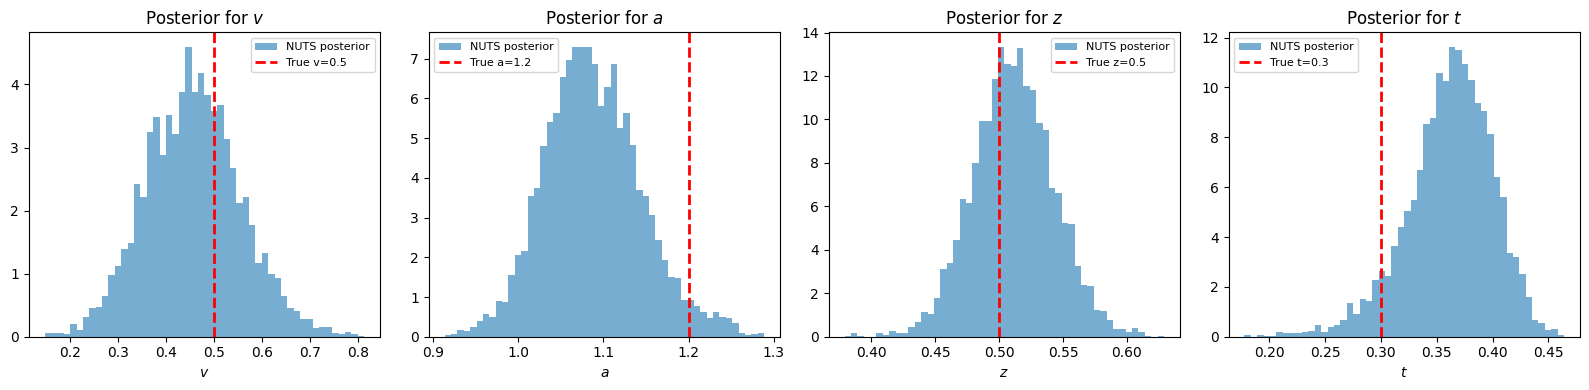

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, (name, true_val) in enumerate([
    ("v", v_true), ("a", a_true), ("z", z_true), ("t", t_true)
]):
    samples = trace.posterior[name].values.flatten()
    axes[i].hist(samples, bins=50, density=True, alpha=0.6, label="NUTS posterior")
    axes[i].axvline(true_val, color="r", linestyle="--", linewidth=2, label=f"True {name}={true_val}")
    axes[i].set_xlabel(f"${name}$")
    axes[i].set_title(f"Posterior for ${name}$")
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Discussion

This notebook demonstrates the complete bridge from a trained BayesFlow
`RatioApproximator` to a full PyMC model for the Drift Diffusion Model, using
the `ssm-simulators` `Simulator` class as the data generator.

**What we built manually:**
1. A prior + simulator pipeline using `ssms.Simulator("ddm")`
2. A `RatioApproximator` trained via NRE-C on 4 DDM parameters
3. A JAX-native single-trial function extracted from the network
4. PyTensor Ops with VJP gradients (replicating HSSM's pattern)
5. A `pm.Distribution` usable in any PyMC model
6. Full NUTS sampling via numpyro with 4 inferred parameters

**How HSSM automates this:**
- HSSM ships pre-trained ONNX likelihood networks for many SSM models
- It uses Bambi for formula-based regression on any parameter
- It handles the PyTensor Op wrapping, distribution creation, and
  parameter management automatically via `hssm.HSSM(...)`
- The architecture shown here is exactly what HSSM does internally --
  this notebook makes each step explicit

**Next steps:**
- Add regression on DDM parameters (e.g., drift rate varies with condition)
- Use a `SummaryNetwork` for multi-trial amortization
- Connect to HSSM directly for production workflows